In [19]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print("Număr exemple:", X.shape[0])
print("Dimensiune caracteristici:", X.shape[1])
print("Denumiri coloane:", iris.feature_names)
print("Nume clase:", iris.target_names)

Număr exemple: 150
Dimensiune caracteristici: 4
Denumiri coloane: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nume clase: ['setosa' 'versicolor' 'virginica']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Înainte scalare:\n", X_train[:3])
print("\nDupă scalare:\n", X_train_scaled[:3])

Înainte scalare:
 [[4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]]

După scalare:
 [[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]]


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("Acuratețe (k=3):", accuracy)

Acuratețe (k=3): 1.0


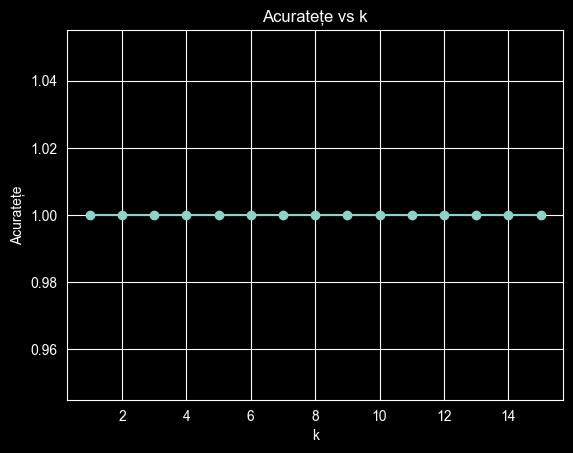

In [23]:
import matplotlib.pyplot as plt

k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k")
plt.ylabel("Acuratețe")
plt.title("Acuratețe vs k")
plt.show()

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

print("Matrice de confuzie:\n", confusion_matrix(y_test, y_pred))

print("\nRaport clasificare:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Matrice de confuzie:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Raport clasificare:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



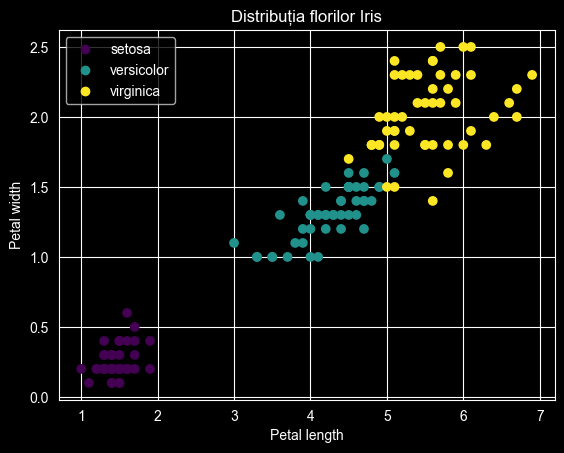

In [25]:
from matplotlib.pyplot import scatter

l = plt.scatter(X[:, 2], X[:, 3], c=y, cmap='viridis')
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Distribuția florilor Iris")
plt.legend(handles=l.legend_elements()[0], labels=iris.target_names.tolist())
plt.show()

In [26]:
# Input utilizator
pl = float(input("Petal length: "))
pw = float(input("Petal width: "))
sl = float(input("Sepal length: "))
sw = float(input("Sepal width: "))

new_flower = [[sl, sw, pl, pw]]

# Scalare
new_flower_scaled = scaler.transform(new_flower)

# Predicție
prediction = knn.predict(new_flower_scaled)

print("Clasa prezisă:", iris.target_names[prediction][0])

Clasa prezisă: versicolor
